# Differential Expression Analysis of the ALL Chiaretti Microarray Dataset with pylimma

This tutorial walks through a pre-normalised microarray workflow.
The expression matrix arrives RMA-normalised, so voom is skipped;
the analysis goes straight from the matrix to `lm_fit`.


**R-parity validation**: the sibling notebook [`all_R_vs_Python.ipynb`](all_R_vs_Python.ipynb) runs R limma 3.66.0 on the same input and compares the outputs numerically.

## Dataset

**Chiaretti et al. 2004, *Blood* 103:2771-2778**: Acute Lymphoblastic Leukemia gene-expression profiles from 128 patients on Affymetrix HG-U95Av2 arrays. The shipped matrix is the 12,625-probe RMA-normalised expression set from the `BioBase::ALL` Bioconductor package.

Biological question: B-cell (`B`) vs T-cell (`T`) derived leukemia
cases.

## Pipeline

1. Load expression matrix + phenotype targets
2. Per-sample distribution QC (boxplot)
3. log-expression kernel density (sanity check)
4. MDS (coloured by BT)
5. Design matrix
6. `lm_fit` + `contrasts_fit`
7. Empirical Bayes moderation
8. Top table and DE calling
9. MD + volcano plots
10. Heatmap of top 50 DE probes (row-ordered by signed t)
11. Summary


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'data'))

import pylimma
import generate_data as gd

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 10)

# Shared plotting helpers used by every tutorial.

def _log_cpm(mat, lib_size):
    cpm = mat.div(lib_size, axis=1) * 1e6 if hasattr(mat, 'div') \
          else (mat / lib_size) * 1e6
    return np.log2(cpm + 1e-2)


def plot_log_cpm_density(mat, ax, title=""):
    '''Kernel-smoothed log-CPM density, one line per sample.

    Matches edgeR/limma's standard density plot (limma User's Guide
    Figure 15.1): a Gaussian KDE per sample drawn on a shared grid.
    '''
    from scipy.stats import gaussian_kde
    arr = mat.values if hasattr(mat, 'values') else np.asarray(mat)
    # Shared evaluation grid spanning the combined range.
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    grid = np.linspace(lo, hi, 200)
    for j in range(arr.shape[1]):
        col = arr[:, j]
        col = col[np.isfinite(col)]
        if col.size < 2:
            continue
        kde = gaussian_kde(col)
        ax.plot(grid, kde(grid), linewidth=0.8, alpha=0.7)
    ax.set_xlabel('log2 CPM')
    ax.set_ylabel('Density')
    ax.set_title(title)


def mds_coords(mat, top=500):
    '''Pairwise leading-logFC MDS, matching R limma's plotMDS.default.

    Returns the (n_samples, ndim) coordinate matrix and the percent of
    variance explained per dimension. We reuse pylimma's private
    _mds_coordinates for consistency with plot_mds().
    '''
    from pylimma.plotting import _mds_coordinates
    r = _mds_coordinates(np.asarray(mat, dtype=np.float64), top=top,
                         gene_selection='pairwise', ndim=2)
    lam = np.maximum(r['eigen_values'], 0.0)
    coords = r['eigen_vectors'] * np.sqrt(lam)
    return coords, r['var_explained']


def plot_mds_coloured(mat, groups, ax, top=500, title='MDS'):
    '''MDS scatter plot coloured by sample group.'''
    coords, var_exp = mds_coords(mat, top=top)
    pct = np.round(var_exp * 100).astype(int)
    groups = np.asarray(groups)
    levels = sorted(pd.unique(groups))
    palette = plt.get_cmap('tab10').colors
    for k, level in enumerate(levels):
        m = groups == level
        ax.scatter(coords[m, 0], coords[m, 1],
                   s=55, color=palette[k % len(palette)],
                   label=str(level), edgecolor='k', linewidth=0.3)
    ax.axhline(0, color='grey', linewidth=0.4, linestyle=':')
    ax.axvline(0, color='grey', linewidth=0.4, linestyle=':')
    ax.set_xlabel(f'Leading logFC dim 1 ({pct[0]}%)')
    ax.set_ylabel(f'Leading logFC dim 2 ({pct[1]}%)')
    ax.set_title(title)
    ax.legend(fontsize=8, frameon=False)


def plot_heatmap(E, groups, fit, n_top=50, ax=None):
    '''Heatmap of top-n DE rows showing BOTH directions.

    Picks the top n/2 genes with the most positive t and the top n/2
    with the most negative t (by smallest p within each side), then
    stacks them - up-regulated in the contrast at top, down-regulated
    at bottom. Row z-scored.'''
    t = np.asarray(fit['t']).ravel()
    p = np.asarray(fit['p_value']).ravel()
    half = n_top // 2
    up_pool   = np.where(t > 0)[0]
    down_pool = np.where(t < 0)[0]
    top_up    = up_pool[np.argsort(p[up_pool])[:half]]
    top_down  = down_pool[np.argsort(p[down_pool])[:n_top - half]]
    # Sort each block by signed t descending so most-up is top and
    # most-down is bottom.
    top_up   = top_up[np.argsort(-t[top_up])]
    top_down = top_down[np.argsort(-t[top_down])]
    ordered  = np.concatenate([top_up, top_down])

    mat = E[ordered]
    col_order = np.argsort(groups)
    mat_sorted = mat[:, col_order]
    z = (mat_sorted - mat_sorted.mean(axis=1, keepdims=True)) / \
        (mat_sorted.std(axis=1, keepdims=True) + 1e-8)

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(z, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
    ax.set_xticks(range(len(col_order)))
    ax.set_xticklabels(np.asarray(groups)[col_order], rotation=90, fontsize=6)
    ax.set_yticks([])
    ax.set_title(f'Top {n_top} DE genes (top {half} up + top {n_top - half} down; row z-scored)')
    return ax, im, ordered


## 1. Load the expression matrix + phenotype targets

In [2]:
data = gd.load_all()
expr    = data['expr']
targets = data['targets']
print(f"expression matrix: {expr.shape}  (probes x samples)")
group = targets["BT"].astype(str).str[0]
print(f"\nBT breakdown:")
print(group.value_counts())
targets[['BT', 'mol.biol', 'sex', 'age']].head()

expression matrix: (12625, 128)  (probes x samples)

BT breakdown:
BT
B    95
T    33
Name: count, dtype: int64


,BT,mol.biol,sex,age
01005,B2,BCR/ABL,M,53.0
01010,B2,NEG,M,19.0
03002,B4,BCR/ABL,F,52.0
04006,B1,ALL1/AF4,M,38.0
04007,B2,NEG,M,57.0


## 2. Per-sample distribution QC

/var/folders/0x/4309q_jn5xbf3zzq_4hcp2100000gn/T/ipykernel_99358/2015273228.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(expr.iloc[:, :40].values, labels=expr.columns[:40],


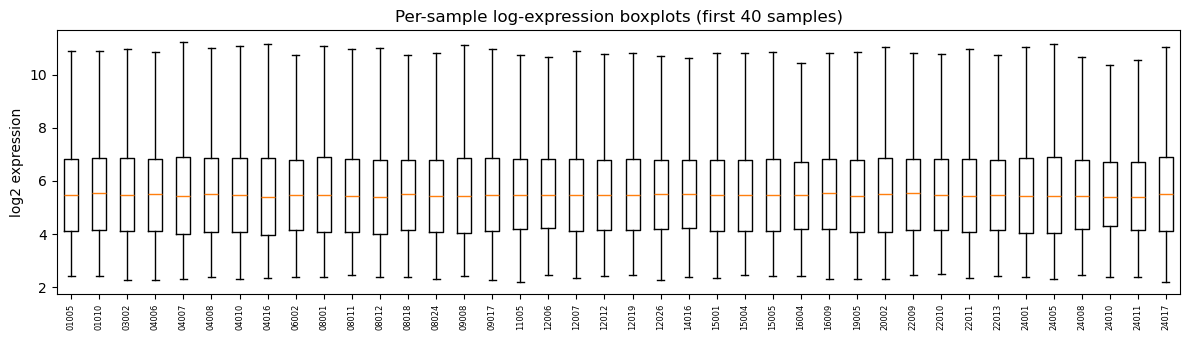

In [3]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.boxplot(expr.iloc[:, :40].values, labels=expr.columns[:40],
           showfliers=False)
ax.set_xticklabels(expr.columns[:40], rotation=90, fontsize=6)
ax.set_ylabel('log2 expression')
ax.set_title('Per-sample log-expression boxplots (first 40 samples)')
fig.tight_layout()
plt.show()

## 3. log-expression density (KDE)

Kernel density per sample. After RMA all samples should be nearly
super-imposed - a visible outlier would warrant follow-up before
differential analysis.

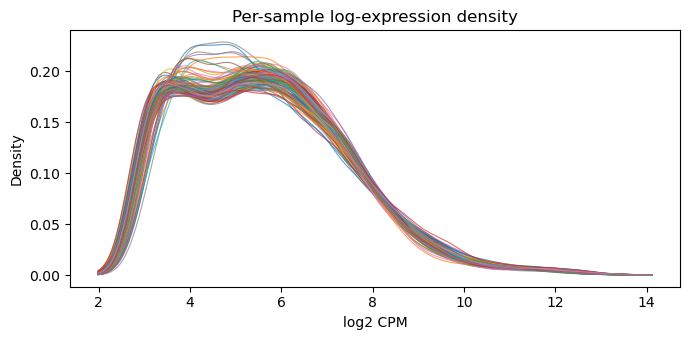

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
plot_log_cpm_density(expr, ax, 'Per-sample log-expression density')
fig.tight_layout()
plt.show()

## 4. MDS (coloured by BT)

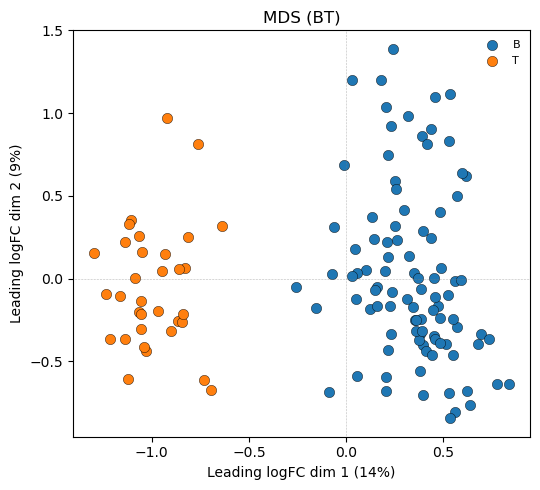

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5))
plot_mds_coloured(expr.values, group.values, ax,
                  top=500, title='MDS (BT)')
fig.tight_layout()
plt.show()

## 5. Design matrix

In [6]:
design, C = gd.build_two_group_design(group)
design_df = pd.DataFrame(design, index=expr.columns,
                         columns=sorted(group.unique()))
print(f"Design: {design_df.shape}, contrast = T - B")
design_df.head(8)

Design: (128, 2), contrast = T - B


,B,T
01005,1.0,0.0
01010,1.0,0.0
03002,1.0,0.0
04006,1.0,0.0
04007,1.0,0.0
04008,1.0,0.0
04010,1.0,0.0
04016,1.0,0.0


## 6. Fit linear models and contrasts (no voom)

In [7]:
fit = pylimma.lm_fit(expr.values, design)
fit = pylimma.contrasts_fit(fit, contrasts=C)
print(f"coefficients shape: {fit['coefficients'].shape}")

/Users/John/miniconda3/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


coefficients shape: (12625, 1)


## 7. Empirical Bayes moderation

In [8]:
fit = pylimma.e_bayes(fit)
print(f"s2_prior: {fit['s2_prior']:.4f}")
print(f"df_prior: {fit['df_prior']:.2f}")

s2_prior: 0.0842
df_prior: 3.03


## 8. Top table

In [9]:
tt = pylimma.top_table(fit, coef=0, number=np.inf, sort_by='p')
tt.index = expr.index[np.argsort(np.asarray(fit['p_value']).ravel())]
print(f"DE calls at adj_p_value < 0.05: {(tt['adj_p_value'] < 0.05).sum():,} probes")
tt.head(10)

DE calls at adj_p_value < 0.05: 3,024 probes


,log_fc,ave_expr,t,p_value,adj_p_value,b
38319_at,4.655042,6.041217,35.302014,3.665982e-68,4.628303e-64,142.887385
38147_at,3.154743,4.582970,26.368452,8.329164e-54,5.257785e-50,111.276776
33238_at,3.102294,7.292159,22.711375,6.493588e-47,2.732718e-43,95.863304
35016_at,-3.214222,10.337892,-22.347402,3.433264e-46,1.083624e-42,94.239065
2059_s_at,2.668482,7.232735,22.156246,8.286073e-46,2.092233e-42,93.379248
37039_at,-3.265990,11.072596,-21.343275,3.694071e-44,7.772940e-41,89.669946
38095_i_at,-3.762299,10.228156,-20.426219,2.955978e-42,5.331317e-39,85.382469
38833_at,-2.966787,10.144085,-19.764032,7.473721e-41,1.179447e-37,82.217871
33039_at,1.812889,3.619621,19.685785,1.098739e-40,1.541287e-37,81.840104
38096_f_at,-4.248782,9.169628,-19.055233,2.522408e-39,3.184540e-36,78.766423


## 9. MD + volcano plots

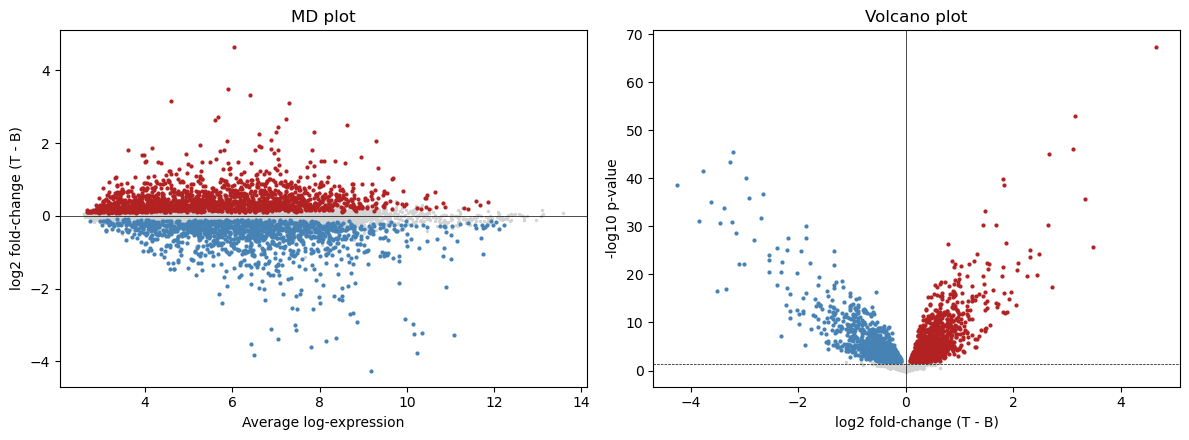

In [10]:
logFC = fit['coefficients'][:, 0]
AveExpr = fit.get('Amean') if fit.get('Amean') is not None \
          else expr.mean(axis=1).values
adj_sig = pylimma.decide_tests(fit, p_value=0.05).ravel() != 0

fig, (axMD, axV) = plt.subplots(1, 2, figsize=(12, 4.5))
# MD
axMD.scatter(AveExpr[~adj_sig], logFC[~adj_sig], s=2, c='lightgrey')
axMD.scatter(AveExpr[adj_sig & (logFC > 0)],
             logFC[adj_sig & (logFC > 0)], s=4, c='firebrick')
axMD.scatter(AveExpr[adj_sig & (logFC < 0)],
             logFC[adj_sig & (logFC < 0)], s=4, c='steelblue')
axMD.axhline(0, color='k', linewidth=0.5)
axMD.set_xlabel('Average log-expression')
axMD.set_ylabel('log2 fold-change (T - B)')
axMD.set_title('MD plot')

# Volcano
p = np.asarray(fit['p_value']).ravel()
neglogp = -np.log10(np.maximum(p, 1e-300))
axV.scatter(logFC[~adj_sig], neglogp[~adj_sig], s=2, c='lightgrey')
axV.scatter(logFC[adj_sig & (logFC > 0)],
            neglogp[adj_sig & (logFC > 0)], s=4, c='firebrick')
axV.scatter(logFC[adj_sig & (logFC < 0)],
            neglogp[adj_sig & (logFC < 0)], s=4, c='steelblue')
axV.axhline(-np.log10(0.05), color='k', linewidth=0.5, linestyle='--')
axV.axvline(0, color='k', linewidth=0.5)
axV.set_xlabel('log2 fold-change (T - B)')
axV.set_ylabel('-log10 p-value')
axV.set_title('Volcano plot')
fig.tight_layout()
plt.show()

## 10. Heatmap of top 50 DE probes

Rows ordered by signed t-statistic (up-regulated at top,
down-regulated at bottom). Columns grouped by BT.

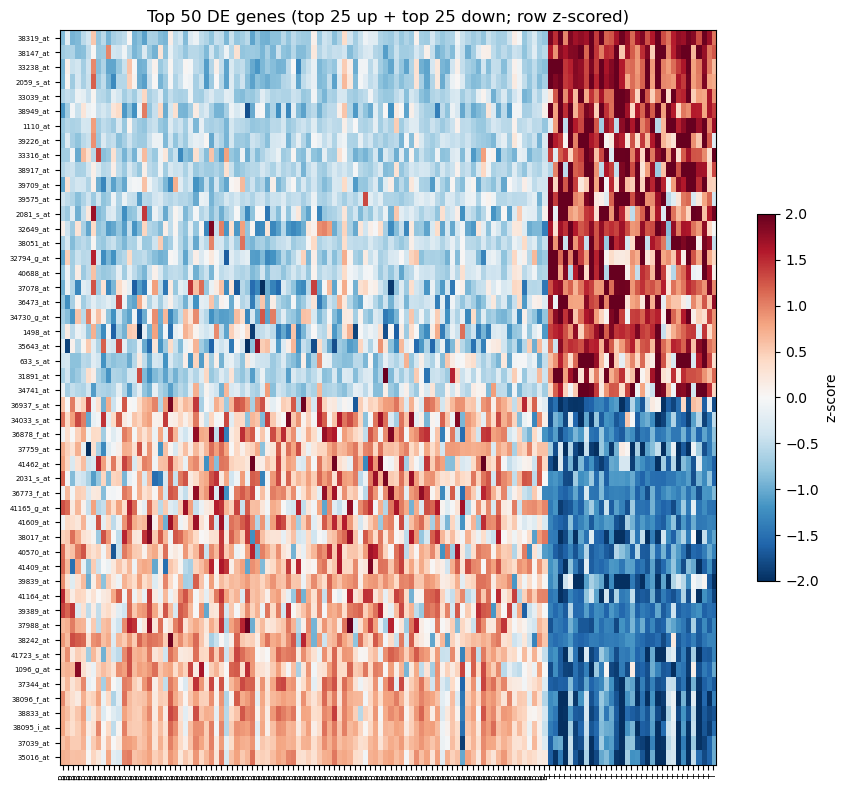

In [11]:
fig, ax = plt.subplots(figsize=(9, 8))
ax, im, ordered = plot_heatmap(expr.values, group.values, fit,
                                n_top=50, ax=ax)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(expr.index[ordered], fontsize=5)
fig.colorbar(im, ax=ax, shrink=0.5, label='z-score')
fig.tight_layout()
plt.show()